# Experiment 1: Cross-Channel Ambiguity Calibration

Jointly calibrates $\sigma$ and $T_{\text{thresh}}$ for LogNormal $r$ and $\omega$
distributions (Experiment~52) to achieve the 8--12\% balanced cross-channel error
target. Also runs the R2.5 reviewer ablation (hard-clip vs.\ truncated-Gaussian).

## Run History

| Run | Date | $\sigma$ | $T_{\text{thresh}}$ | $r$ | $\omega$ | Key result |
|-----|------|---------|-------------------|-----|---------|--------|
| 1 | 2026-05 | $0.838\,T_u$ | $2.17\,T_u$ | $\mathcal{U}[2.5,4.5]$ | $\mathcal{U}[0.8,1.3]$ | 9.43% overall, balanced |
| **3** | **2026-06** | **joint calibration below** | **joint calibration below** | **LogNormal(1.2269, 0.2916)** | **LogNormal(0.0360, 0.2446)** | **TBD** |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

SEED = 42
rng  = np.random.default_rng(SEED)
print(f"NumPy {np.__version__},  seed={SEED}")


NumPy 2.3.4,  seed=42


## Protocol Parameters

In [2]:
WPM = 20
T_U = 1200.0 / WPM             # 60.0 ms at 20 WPM

# LogNormal parameters for r and omega (MLE fit, Experiment 52, n=36 recordings)
MU_R,     SIGMA_R     = 1.2269, 0.2916
MU_OMEGA, SIGMA_OMEGA = 0.0360, 0.2446

TARGET_ERROR = 0.09            # ~9%: lower portion of the 8-12% design band

# Sample sizes
N_CAL    = 1_000_000  # per sigma level in joint calibration (500k dots + 500k dashes)
N_SWEEP  =   200_000  # per sigma level in sigma sweep
N_VERIFY =   500_000  # high-precision verification

# Adopted values — set by joint calibration below; placeholder until then
SIGMA_FRAC    = None
T_THRESH_FRAC = None
T_THRESH      = None

print(f'T_u            = {T_U:.1f} ms')
print(f'r  ~ LogNormal (mu={MU_R}, sigma={SIGMA_R})  median={np.exp(MU_R):.3f}')
print(f'w  ~ LogNormal (mu={MU_OMEGA}, sigma={SIGMA_OMEGA})  median={np.exp(MU_OMEGA):.3f}')
print(f'Target error   = {TARGET_ERROR*100:.1f}%')


T_u            = 60.0 ms
r  ~ LogNormal (mu=1.2269, sigma=0.2916)  median=3.411
w  ~ LogNormal (mu=0.036, sigma=0.2446)  median=1.037
Target error   = 9.0%


## Simulation Function

In [3]:
def simulate_marks(n_dots, n_dashes, sigma, t_u, t_thresh, rng,
                   clip_mode='hard'):
    """
    Generate dot and dash marks under TEMPO stochastic corruption and count
    cross-channel misclassifications.  r and omega sampled per-mark from
    LogNormal distributions (Experiment 52).

    clip_mode:
      'hard'      - floor at 0.1 T_u (paper default)
      'truncated' - rejection-sample until duration >= 0.1 T_u (R2.5 ablation)
    """
    clip = 0.1 * t_u

    omega_dot  = rng.lognormal(MU_OMEGA, SIGMA_OMEGA, size=n_dots)
    omega_dash = rng.lognormal(MU_OMEGA, SIGMA_OMEGA, size=n_dashes)
    r_dash     = rng.lognormal(MU_R,     SIGMA_R,     size=n_dashes)

    t_dot_w  = 1.0    * t_u * omega_dot
    t_dash_w = r_dash * t_u * omega_dash

    if sigma > 0:
        t_dot_f  = t_dot_w  + rng.normal(0, sigma, size=n_dots)
        t_dash_f = t_dash_w + rng.normal(0, sigma, size=n_dashes)
    else:
        t_dot_f  = t_dot_w.copy()
        t_dash_f = t_dash_w.copy()

    if clip_mode == 'hard':
        dot_clipped  = int((t_dot_f  < clip).sum())
        dash_clipped = int((t_dash_f < clip).sum())
        t_dot_f  = np.maximum(t_dot_f,  clip)
        t_dash_f = np.maximum(t_dash_f, clip)
    else:
        dot_clipped = dash_clipped = 0
        bad = t_dot_f < clip
        while bad.any():
            dot_clipped += int(bad.sum())
            t_dot_f[bad] = t_dot_w[bad] + rng.normal(0, sigma, size=int(bad.sum()))
            bad = t_dot_f < clip
        bad = t_dash_f < clip
        while bad.any():
            dash_clipped += int(bad.sum())
            t_dash_f[bad] = t_dash_w[bad] + rng.normal(0, sigma, size=int(bad.sum()))
            bad = t_dash_f < clip

    dot_miscl  = t_dot_f  >= t_thresh
    dash_miscl = t_dash_f <  t_thresh

    return {
        "dot_error_rate":     dot_miscl.mean(),
        "dash_error_rate":    dash_miscl.mean(),
        "overall_error_rate": (dot_miscl.sum() + dash_miscl.sum()) / (n_dots + n_dashes),
        "dot_durations":      t_dot_f,
        "dash_durations":     t_dash_f,
        "dot_clip_frac":      dot_clipped  / n_dots,
        "dash_clip_frac":     dash_clipped / n_dashes,
    }


## Joint Calibration: Balance Locus

For each $\sigma$ in $[0.45, 0.85]\,T_u$, binary-searches for the $T_{\text{thresh}}$
that equalises dot and dash error rates (ratio $\to$ 1.0).  This maps the
one-dimensional *balance locus* in $(\sigma, T_{\text{thresh}})$ space and
identifies the point whose balanced error rate is closest to the 9\% target.

$N = 1{,}000{,}000$ marks per $\sigma$ level (500k dots + 500k dashes).


In [4]:
print('Balance locus sweep  (binary-search T_thresh for each sigma)')
print(f'{"sigma/Tu":>9}  {"T_thr/Tu":>9}  {"dot%":>8}  {"dash%":>8}  '
      f'{"balanced%":>10}  {"ratio":>7}')
print('-' * 62)

locus = []
nh = N_CAL // 2

for sf in np.arange(0.45, 0.851, 0.025):
    sigma = sf * T_U
    crng  = np.random.default_rng(int(round(sf * 1000)))

    # Generate mark pools once for this sigma
    omega_dot_c  = crng.lognormal(MU_OMEGA, SIGMA_OMEGA, nh)
    omega_dash_c = crng.lognormal(MU_OMEGA, SIGMA_OMEGA, nh)
    r_dash_c     = crng.lognormal(MU_R,     SIGMA_R,     nh)
    clip         = 0.1 * T_U

    t_dot_c  = np.maximum(T_U * omega_dot_c
                          + crng.normal(0, sigma, nh), clip)
    t_dash_c = np.maximum(r_dash_c * T_U * omega_dash_c
                          + crng.normal(0, sigma, nh), clip)

    # Binary search: find T_thresh where dot_error == dash_error
    # As T_thresh increases: dot_error decreases, dash_error increases
    # So: dot_error > dash_error  =>  T_thresh too low  =>  raise upper bound... wait
    # dot miscl = t_dot >= T_thresh  (dot too long)
    # dash miscl = t_dash < T_thresh (dash too short)
    # As T_thresh rises: fewer dots misclassified (dot_error falls),
    #                    more dashes misclassified (dash_error rises)
    # Balance point: find T_thresh where dot_error == dash_error
    # If dot_error > dash_error: T_thresh too low -> increase T_thresh
    # If dot_error < dash_error: T_thresh too high -> decrease T_thresh
    lo_t, hi_t = 0.5 * T_U, 3.5 * T_U
    for _ in range(60):
        mid = (lo_t + hi_t) / 2
        de  = (t_dot_c  >= mid).mean()
        dse = (t_dash_c <  mid).mean()
        if de > dse:
            lo_t = mid   # dot error too high -> raise T_thresh
        else:
            hi_t = mid   # dash error too high -> lower T_thresh

    t_bal = (lo_t + hi_t) / 2
    de    = (t_dot_c  >= t_bal).mean()
    dse   = (t_dash_c <  t_bal).mean()
    ov    = (de + dse) / 2
    ratio = de / dse if dse > 0 else float('inf')

    locus.append({'sigma_frac': sf, 'thresh_frac': t_bal / T_U,
                  'dot': de, 'dash': dse, 'overall': ov, 'ratio': ratio})

    marker = '  <- ~9% target' if abs(ov - TARGET_ERROR) < 0.010 else ''
    print(f'{sf:9.3f}  {t_bal/T_U:9.4f}  {de*100:8.4f}  {dse*100:8.4f}  '
          f'{ov*100:10.4f}  {ratio:7.4f}{marker}')

# Select the locus point closest to the target error
best = min(locus, key=lambda r: abs(r['overall'] - TARGET_ERROR))
print(f'\nBest match: sigma={best["sigma_frac"]:.3f} Tu'
      f'  T_thresh={best["thresh_frac"]:.4f} Tu'
      f'  balanced={best["overall"]*100:.4f}%'
      f'  ratio={best["ratio"]:.4f}')

# Adopt these values
SIGMA_FRAC    = round(best['sigma_frac'], 3)
T_THRESH_FRAC = round(best['thresh_frac'], 2)
T_THRESH      = T_THRESH_FRAC * T_U
print(f'\nAdopted (rounded):')
print(f'  sigma     = {SIGMA_FRAC} T_u = {SIGMA_FRAC*T_U:.2f} ms')
print(f'  T_thresh  = {T_THRESH_FRAC} T_u = {T_THRESH:.2f} ms')


Balance locus sweep  (binary-search T_thresh for each sigma)
 sigma/Tu   T_thr/Tu      dot%     dash%   balanced%    ratio
--------------------------------------------------------------
    0.450     1.8585    6.7580    6.7580      6.7580   1.0000
    0.475     1.8715    7.1986    7.1984      7.1985   1.0000


    0.500     1.8841    7.6308    7.6306      7.6307   1.0000
    0.525     1.8985    8.0810    8.0808      8.0809   1.0000  <- ~9% target
    0.550     1.9109    8.4300    8.4300      8.4300   1.0000  <- ~9% target


    0.575     1.9223    8.9198    8.9196      8.9197   1.0000  <- ~9% target
    0.600     1.9374    9.3046    9.3044      9.3045   1.0000  <- ~9% target
    0.625     1.9516    9.7660    9.7658      9.7659   1.0000  <- ~9% target


    0.650     1.9633   10.1924   10.1922     10.1923   1.0000
    0.675     1.9741   10.6980   10.6978     10.6979   1.0000
    0.700     1.9846   11.1152   11.1150     11.1151   1.0000


    0.725     1.9955   11.5068   11.5066     11.5067   1.0000
    0.750     2.0043   11.9354   11.9352     11.9353   1.0000
    0.775     2.0141   12.4036   12.4034     12.4035   1.0000


    0.800     2.0264   12.7784   12.7784     12.7784   1.0000
    0.825     2.0375   13.2222   13.2220     13.2221   1.0000
    0.850     2.0430   13.6438   13.6436     13.6437   1.0000

Best match: sigma=0.575 Tu  T_thresh=1.9223 Tu  balanced=8.9197%  ratio=1.0000

Adopted (rounded):
  sigma     = 0.575 T_u = 34.50 ms
  T_thresh  = 1.92 T_u = 115.20 ms


## Figure: Balance Locus

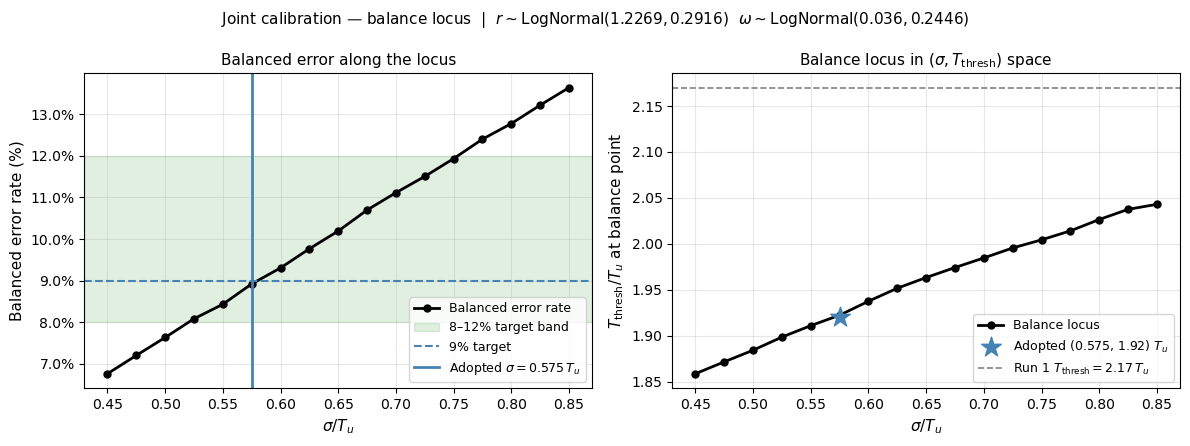

Saved -> figures/exp1_joint_calibration.pdf


In [5]:
sfs  = np.array([r['sigma_frac']  for r in locus])
tfs  = np.array([r['thresh_frac'] for r in locus])
ovs  = np.array([r['overall']     for r in locus]) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: balanced error rate along the locus
ax1.plot(sfs, ovs, 'k-o', ms=5, lw=2, label='Balanced error rate')
ax1.axhspan(8, 12, alpha=0.12, color='green', label='8–12% target band')
ax1.axhline(TARGET_ERROR * 100, color='steelblue', ls='--', lw=1.5,
            label=f'{TARGET_ERROR*100:.0f}% target')
ax1.axvline(SIGMA_FRAC, color='steelblue', lw=2.0,
            label=f'Adopted $\sigma = {SIGMA_FRAC}\,T_u$')
ax1.set_xlabel('$\sigma / T_u$', fontsize=11)
ax1.set_ylabel('Balanced error rate (%)', fontsize=11)
ax1.set_title('Balanced error along the locus', fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Right: the locus in (sigma, T_thresh) space
ax2.plot(sfs, tfs, 'k-o', ms=5, lw=2, label='Balance locus')
ax2.scatter([SIGMA_FRAC], [T_THRESH_FRAC], marker='*', s=220,
            color='steelblue', zorder=5,
            label=f'Adopted ({SIGMA_FRAC}, {T_THRESH_FRAC}) $T_u$')
ax2.axhline(2.17, color='grey', ls='--', lw=1.2,
            label='Run 1 $T_{\mathrm{thresh}} = 2.17\,T_u$')
ax2.set_xlabel('$\sigma / T_u$', fontsize=11)
ax2.set_ylabel('$T_{\mathrm{thresh}} / T_u$ at balance point', fontsize=11)
ax2.set_title('Balance locus in $(\sigma, T_{\mathrm{thresh}})$ space', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.suptitle(
    f'Joint calibration — balance locus  |  '
    f'$r \sim \mathrm{{LogNormal}}({MU_R}, {SIGMA_R})$  '
    f'$\omega \sim \mathrm{{LogNormal}}({MU_OMEGA}, {SIGMA_OMEGA})$',
    fontsize=11)
fig.tight_layout()
plt.savefig('../figures/exp1_joint_calibration.pdf', bbox_inches='tight')
plt.show()
print('Saved -> figures/exp1_joint_calibration.pdf')


## Sigma Sweep

Sweeps $\sigma$ from 0 to $1.5\,T_u$ at the adopted
$T_{\text{thresh}}$, producing the paper calibration figure.


In [6]:
def run_sigma_sweep(t_thresh, label, n_per=N_SWEEP, seed=0):
    srng    = np.random.default_rng(seed)
    results = []
    print(f'Sigma sweep  T_thresh={t_thresh/T_U:.2f} Tu  ({label})')
    print(f'{"sigma/Tu":>9}  {"dot%":>8}  {"dash%":>9}  {"overall%":>9}')
    print('-' * 46)
    for frac in np.arange(0.0, 1.51, 0.05):
        sigma = frac * T_U
        res   = simulate_marks(n_per // 2, n_per // 2, sigma, T_U, t_thresh, srng)
        results.append({
            'sigma_frac':         frac,
            'dot_error_rate':     res['dot_error_rate'],
            'dash_error_rate':    res['dash_error_rate'],
            'overall_error_rate': res['overall_error_rate'],
        })
        marker = '  <- paper sigma' if abs(frac - SIGMA_FRAC) < 0.013 else ''
        print(f"{frac:9.2f}  {res['dot_error_rate']*100:8.4f}  "
              f"{res['dash_error_rate']*100:9.4f}  "
              f"{res['overall_error_rate']*100:9.4f}{marker}")
    return results

sweep = run_sigma_sweep(T_THRESH, f'T_thresh={T_THRESH_FRAC} Tu (adopted)', seed=10)


Sigma sweep  T_thresh=1.92 Tu  (T_thresh=1.92 Tu (adopted))
 sigma/Tu      dot%      dash%   overall%
----------------------------------------------
     0.00    0.6130     5.5390     3.0760
     0.05    0.5980     5.5210     3.0595
     0.10    0.6750     5.5090     3.0920
     0.15    0.8480     5.6430     3.2455
     0.20    1.1630     5.9760     3.5695
     0.25    1.5290     6.1590     3.8440
     0.30    2.2160     6.2560     4.2360
     0.35    3.0340     6.7380     4.8860
     0.40    4.0840     7.3460     5.7150
     0.45    5.4720     7.6140     6.5430
     0.50    6.6280     8.1030     7.3655
     0.55    8.2310     8.5820     8.4065
     0.60    9.7200     9.1060     9.4130
     0.65   11.2900     9.6730    10.4815
     0.70   12.8080    10.0710    11.4395
     0.75   14.1850    10.5950    12.3900
     0.80   15.6080    11.1730    13.3905
     0.85   17.0240    11.7170    14.3705
     0.90   18.0680    12.0430    15.0555
     0.95   19.2960    12.6090    15.9525
     1.00  

## Paper Figure: Ambiguity Calibration

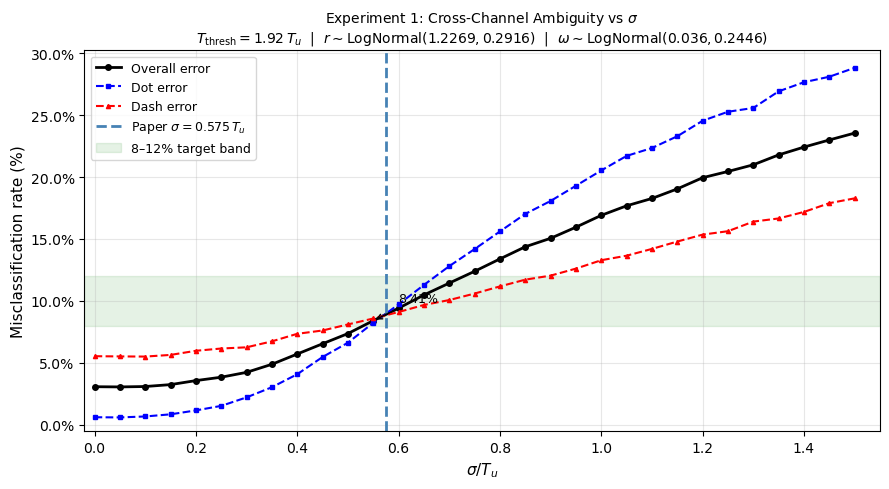

Saved -> figures/exp1_ambiguity_calibration.pdf


In [7]:
s_fracs = np.array([r['sigma_frac']        for r in sweep])
s_ov    = np.array([r['overall_error_rate'] for r in sweep])
s_dot   = np.array([r['dot_error_rate']     for r in sweep])
s_dash  = np.array([r['dash_error_rate']    for r in sweep])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(s_fracs, s_ov  * 100, 'k-o',  lw=2,   ms=4, label='Overall error')
ax.plot(s_fracs, s_dot * 100, 'b--s', lw=1.5, ms=3, label='Dot error')
ax.plot(s_fracs, s_dash* 100, 'r--^', lw=1.5, ms=3, label='Dash error')
ax.axvline(SIGMA_FRAC, color='steelblue', lw=2.0, ls='--',
           label=f'Paper $\sigma = {SIGMA_FRAC}\,T_u$')
ax.axhspan(8, 12, alpha=0.10, color='green', label='8–12% target band')

idx = np.argmin(np.abs(s_fracs - SIGMA_FRAC))
ax.annotate(f'{s_ov[idx]*100:.2f}%',
            xy=(s_fracs[idx], s_ov[idx]*100),
            xytext=(s_fracs[idx] + 0.05, s_ov[idx]*100 + 1.5),
            fontsize=9, arrowprops=dict(arrowstyle='->', lw=1))

ax.set_xlabel('$\sigma / T_u$', fontsize=11)
ax.set_ylabel('Misclassification rate (%)', fontsize=11)
ax.set_title(
    f'Experiment 1: Cross-Channel Ambiguity vs $\sigma$\n'
    f'$T_{{\mathrm{{thresh}}}} = {T_THRESH_FRAC}\,T_u$  |  '
    f'$r \sim \mathrm{{LogNormal}}({MU_R}, {SIGMA_R})$  |  '
    f'$\omega \sim \mathrm{{LogNormal}}({MU_OMEGA}, {SIGMA_OMEGA})$',
    fontsize=10)
ax.set_xlim(-0.02, s_fracs.max() + 0.05)
ax.set_ylim(-0.5, None)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig('../figures/exp1_ambiguity_calibration.pdf', bbox_inches='tight')
plt.show()
print('Saved -> figures/exp1_ambiguity_calibration.pdf')


## High-Precision Verification

In [8]:
def wilson_ci(p, n, z=1.96):
    lo = (p + z**2/(2*n) - z*np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / (1 + z**2/n)
    hi = (p + z**2/(2*n) + z*np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / (1 + z**2/n)
    return lo, hi

vrng  = np.random.default_rng(200)
nh    = N_VERIFY // 2
res_v = simulate_marks(nh, nh, SIGMA_FRAC * T_U, T_U, T_THRESH, vrng)

dr, dsr = res_v['dot_error_rate'], res_v['dash_error_rate']
ov       = res_v['overall_error_rate']
ratio    = dr / dsr if dsr > 0 else float('inf')
ol, oh   = wilson_ci(ov, N_VERIFY)
dl, dh   = wilson_ci(dr, nh)
sl, sh   = wilson_ci(dsr, nh)

print(f'High-precision verification  N={N_VERIFY:,}')
print(f'  sigma     = {SIGMA_FRAC} T_u = {SIGMA_FRAC*T_U:.2f} ms')
print(f'  T_thresh  = {T_THRESH_FRAC} T_u = {T_THRESH:.2f} ms')
print()
print(f'  Dot  error : {dr*100:.4f}%  95% CI [{dl*100:.4f}%, {dh*100:.4f}%]')
print(f'  Dash error : {dsr*100:.4f}%  95% CI [{sl*100:.4f}%, {sh*100:.4f}%]')
print(f'  Overall    : {ov*100:.4f}%  95% CI [{ol*100:.4f}%, {oh*100:.4f}%]')
print(f'  Ratio      : {ratio:.3f}')
print()
in_band = 8.0 <= ov * 100 <= 12.0
print(f'  In 8-12% target band: {in_band}')
print()
print(f'  Dot  clipping: {res_v["dot_clip_frac"]*100:.4f}%')
print(f'  Dash clipping: {res_v["dash_clip_frac"]*100:.4f}%')

_dot_dur  = res_v['dot_durations']
_dash_dur = res_v['dash_durations']


High-precision verification  N=500,000
  sigma     = 0.575 T_u = 34.50 ms
  T_thresh  = 1.92 T_u = 115.20 ms

  Dot  error : 9.0164%  95% CI [8.9048%, 9.1293%]
  Dash error : 8.8848%  95% CI [8.7739%, 8.9970%]
  Overall    : 8.9506%  95% CI [8.8718%, 9.0300%]
  Ratio      : 1.015

  In 8-12% target band: True

  Dot  clipping: 6.1848%
  Dash clipping: 0.0348%


## Figure: Mark Duration Distributions

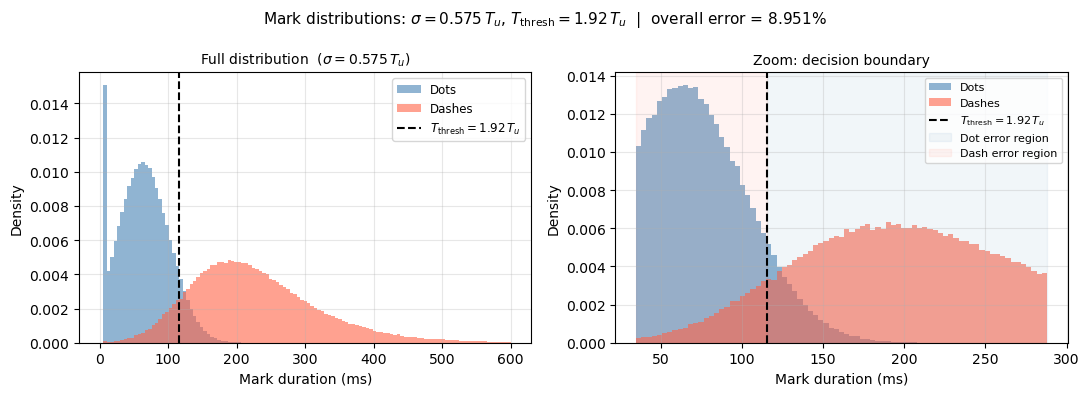

Saved -> figures/exp1_duration_distributions.pdf


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
bins = np.linspace(0, min(_dash_dur.max(), 10 * T_U), 120)
ax.hist(_dot_dur,  bins=bins, alpha=0.6, color='steelblue', label='Dots',   density=True)
ax.hist(_dash_dur, bins=bins, alpha=0.6, color='tomato',    label='Dashes', density=True)
ax.axvline(T_THRESH, color='black', ls='--', lw=1.5,
           label=f'$T_{{\mathrm{{thresh}}}} = {T_THRESH_FRAC}\,T_u$')
ax.set_xlabel('Mark duration (ms)', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.set_title(f'Full distribution  ($\sigma = {SIGMA_FRAC}\,T_u$)', fontsize=10)
ax.legend(fontsize=8.5)
ax.grid(True, alpha=0.3)

ax = axes[1]
zlo, zhi = T_THRESH * 0.3, T_THRESH * 2.5
m1 = (_dot_dur  >= zlo) & (_dot_dur  <= zhi)
m2 = (_dash_dur >= zlo) & (_dash_dur <= zhi)
bz = np.linspace(zlo, zhi, 80)
ax.hist(_dot_dur[m1],  bins=bz, alpha=0.6, color='steelblue', label='Dots',   density=True)
ax.hist(_dash_dur[m2], bins=bz, alpha=0.6, color='tomato',    label='Dashes', density=True)
ax.axvline(T_THRESH, color='black', ls='--', lw=1.5,
           label=f'$T_{{\mathrm{{thresh}}}} = {T_THRESH_FRAC}\,T_u$')
ax.axvspan(T_THRESH, zhi, alpha=0.07, color='steelblue', label='Dot error region')
ax.axvspan(zlo, T_THRESH, alpha=0.07, color='tomato',    label='Dash error region')
ax.set_xlabel('Mark duration (ms)', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.set_title('Zoom: decision boundary', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.suptitle(
    f'Mark distributions: $\sigma = {SIGMA_FRAC}\,T_u$, '
    f'$T_{{\mathrm{{thresh}}}} = {T_THRESH_FRAC}\,T_u$  |  '
    f'overall error = {ov*100:.3f}%',
    fontsize=11)
fig.tight_layout()
plt.savefig('../figures/exp1_duration_distributions.pdf', bbox_inches='tight')
plt.show()
print('Saved -> figures/exp1_duration_distributions.pdf')


## R2.5 Ablation: Hard-Clip vs Truncated-Gaussian

Compares the hard-clip floor (`max(T_final, 0.1 T_u)`) against a
truncated-Gaussian alternative at the adopted $(\sigma, T_{\text{thresh}})$.


In [10]:
def wilson_result(label, res, n):
    dr_, dsr_ = res['dot_error_rate'], res['dash_error_rate']
    ov_       = res['overall_error_rate']
    ol_, oh_  = wilson_ci(ov_, n)
    rat_      = dr_ / dsr_ if dsr_ > 0 else float('inf')
    print(f'  {label}')
    print(f'    Dot  error   : {dr_*100:.4f}%')
    print(f'    Dash error   : {dsr_*100:.4f}%')
    print(f'    Overall      : {ov_*100:.4f}%  95% CI [{ol_*100:.4f}%, {oh_*100:.4f}%]')
    print(f'    Ratio        : {rat_:.3f}')
    print(f'    Dot  floor   : {res["dot_clip_frac"]*100:.4f}%')
    print(f'    Dash floor   : {res["dash_clip_frac"]*100:.4f}%')
    print()
    return ov_

nh_abl    = N_VERIFY // 2
sigma_abl = SIGMA_FRAC * T_U

print('=== R2.5 Ablation: Hard-clip vs Truncated-Gaussian ===')
print(f'    sigma={SIGMA_FRAC} Tu,  T_thresh={T_THRESH_FRAC} Tu,  N={N_VERIFY:,}')
print()
ov_hc = wilson_result('Hard-clip   (max(T_final, 0.1 T_u))',
    simulate_marks(nh_abl, nh_abl, sigma_abl, T_U, T_THRESH,
                   np.random.default_rng(300), clip_mode='hard'), N_VERIFY)
ov_tg = wilson_result('Truncated-Gaussian (rejection sample >= 0.1 T_u)',
    simulate_marks(nh_abl, nh_abl, sigma_abl, T_U, T_THRESH,
                   np.random.default_rng(301), clip_mode='truncated'), N_VERIFY)

delta = abs(ov_hc - ov_tg) * 100
print(f'Absolute difference: {delta:.4f} pp')
print(f'Conclusion: {"Results equivalent — hard-clip validated." if delta < 1.0 else "Difference > 1 pp — review required."}')


=== R2.5 Ablation: Hard-clip vs Truncated-Gaussian ===
    sigma=0.575 Tu,  T_thresh=1.92 Tu,  N=500,000

  Hard-clip   (max(T_final, 0.1 T_u))
    Dot  error   : 9.0228%
    Dash error   : 8.8708%
    Overall      : 8.9468%  95% CI [8.8680%, 9.0262%]
    Ratio        : 1.017
    Dot  floor   : 6.1312%
    Dash floor   : 0.0384%

  Truncated-Gaussian (rejection sample >= 0.1 T_u)
    Dot  error   : 9.2856%
    Dash error   : 8.8692%
    Overall      : 9.0774%  95% CI [8.9981%, 9.1573%]
    Ratio        : 1.047
    Dot  floor   : 6.7924%
    Dash floor   : 0.0372%

Absolute difference: 0.1306 pp
Conclusion: Results equivalent — hard-clip validated.


## Summary

In [11]:
print('=' * 65)
print('Experiment 1 (Run 3) — Cross-Channel Ambiguity Calibration')
print('=' * 65)
print()
print('Jointly calibrated parameters:')
print(f'  WPM       = {WPM}')
print(f'  T_u       = {T_U:.1f} ms')
print(f'  sigma     = {SIGMA_FRAC} T_u = {SIGMA_FRAC*T_U:.2f} ms')
print(f'  T_thresh  = {T_THRESH_FRAC} T_u = {T_THRESH:.2f} ms')
print(f'  r         ~ LogNormal(mu={MU_R}, sigma={SIGMA_R})')
print(f'  omega     ~ LogNormal(mu={MU_OMEGA}, sigma={SIGMA_OMEGA})')
print()
print(f'High-precision verification (N={N_VERIFY:,}):')
print(f'  Dot  error : {dr*100:.4f}%  [{dl*100:.4f}%, {dh*100:.4f}%]')
print(f'  Dash error : {dsr*100:.4f}%  [{sl*100:.4f}%, {sh*100:.4f}%]')
print(f'  Overall    : {ov*100:.4f}%  95% CI [{ol*100:.4f}%, {oh*100:.4f}%]')
print(f'  Ratio      : {ratio:.3f}')
print(f'  In 8-12% band: {in_band}')
print()
print(f'R2.5 Ablation (hard-clip vs truncated-Gaussian):')
print(f'  Hard-clip  : {ov_hc*100:.4f}%')
print(f'  Truncated  : {ov_tg*100:.4f}%')
print(f'  Difference : {abs(ov_hc-ov_tg)*100:.4f} pp')
print()
print('Figures saved:')
print('  figures/exp1_joint_calibration.pdf')
print('  figures/exp1_ambiguity_calibration.pdf')
print('  figures/exp1_duration_distributions.pdf')


Experiment 1 (Run 3) — Cross-Channel Ambiguity Calibration

Jointly calibrated parameters:
  WPM       = 20
  T_u       = 60.0 ms
  sigma     = 0.575 T_u = 34.50 ms
  T_thresh  = 1.92 T_u = 115.20 ms
  r         ~ LogNormal(mu=1.2269, sigma=0.2916)
  omega     ~ LogNormal(mu=0.036, sigma=0.2446)

High-precision verification (N=500,000):
  Dot  error : 9.0164%  [8.9048%, 9.1293%]
  Dash error : 8.8848%  [8.7739%, 8.9970%]
  Overall    : 8.9506%  95% CI [8.8718%, 9.0300%]
  Ratio      : 1.015
  In 8-12% band: True

R2.5 Ablation (hard-clip vs truncated-Gaussian):
  Hard-clip  : 8.9468%
  Truncated  : 9.0774%
  Difference : 0.1306 pp

Figures saved:
  figures/exp1_joint_calibration.pdf
  figures/exp1_ambiguity_calibration.pdf
  figures/exp1_duration_distributions.pdf
